# Train SAC Diff Drive

Train the continuous differential-drive SAC agent and run a short deterministic evaluation. Outputs are saved inside `Continuous_Diff_Drive/videos`, `Continuous_Diff_Drive/images`, and `Continuous_Diff_Drive/models`.

In [1]:
from pathlib import Path
import sys

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name != "Continuous_Diff_Drive":
        BASE_DIR = BASE_DIR / "Continuous_Diff_Drive"

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from diff_drive_agent import DiffDriveSACAgent
from diff_drive_env import DiffDriveEnv

BASE_DIR

PosixPath('/Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive')

## Configuration

In [2]:
# A room with a few axis-aligned rectangular obstacles.
# Each obstacle is (x, y, width, height) in metres, origin at bottom-left.
# The training environment below samples curriculum obstacles instead of using this fixed list.
OBSTACLES = [
    (2.0, 4.0, 1.5, 0.3),
    (5.0, 2.0, 0.3, 3.0),
    (7.0, 6.0, 1.5, 0.3),
]

ENV_KWARGS = dict(
    room_size       = (10.0, 10.0),
    obstacles       = None,
    random_obst     = True,
    robot_start     = (1.0, 1.0),
    goal_pos        = (8.5, 8.5),
    max_step        = 1200,
    n_lidar_rays    = 16,
    lidar_max_range = 5.0,
    robot_radius    = 0.3,
    dt              = 0.1,
    render_mode     = "rgb_array",

    # Curriculum samples blocked-path and wall-with-gap cases, not only small random blocks.
    obstacle_mode   = "curriculum",
)

NUM_EPISODES  = 3_000
RECORD_EVERY  = 500
LOG_EVERY     = 50

ACTOR_LR      = 3e-4
CRITIC_LR     = 3e-4
ALPHA_LR      = 3e-4
DISCOUNT      = 0.99
TAU           = 0.005
BATCH_SIZE    = 256
BUFFER_SIZE   = 100_000
HIDDEN_DIM    = 64

# SAC starts with random actions to populate the replay buffer before gradient updates.
START_STEPS   = 5_000

# Automatic entropy tuning learns alpha, which controls stochastic exploration.
AUTO_ENTROPY  = True
DEVICE        = "cpu"

RUN_TRAINING = True
LOAD_CHECKPOINT_FOR_EVAL = False

## Output Paths

In [3]:
VIDEO_DIR = BASE_DIR / "videos"
TRAINING_VIDEO_DIR = VIDEO_DIR / "training_sac"
EVALUATION_VIDEO_DIR = VIDEO_DIR / "evaluation_sac"
IMAGE_DIR = BASE_DIR / "images"
MODEL_DIR = BASE_DIR / "models"
CHECKPOINT_PATH = MODEL_DIR / "sac_checkpoint.pt"
PLOT_PATH = IMAGE_DIR / "sac_diff_drive_training_curves.png"
PLOT_PATH2 = IMAGE_DIR / "sac_diff_drive_training_curves2.png"

TRAINING_NAME_PREFIX = "sac_diff_drive_training"
EVALUATION_NAME_PREFIX = "sac_diff_drive_eval_random_obstacles_greedy"

for directory in (TRAINING_VIDEO_DIR, EVALUATION_VIDEO_DIR, IMAGE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

VIDEO_DIR

PosixPath('/Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos')

## Environment and Agent

In [4]:
env = DiffDriveEnv(**ENV_KWARGS)

agent = DiffDriveSACAgent(
    env                       = env,
    actor_lr                  = ACTOR_LR,
    critic_lr                 = CRITIC_LR,
    alpha_lr                  = ALPHA_LR,
    discount                  = DISCOUNT,
    tau                       = TAU,
    batch_size                = BATCH_SIZE,
    buffer_size               = BUFFER_SIZE,
    hidden_dim                = HIDDEN_DIM,
    warmup_steps              = START_STEPS,
    automatic_entropy_tuning  = AUTO_ENTROPY,
    device                    = DEVICE,
)

agent

## Training

In [5]:
if RUN_TRAINING:
    print("=" * 60)
    print("  DiffDrive - SAC Training")
    print(f"  Episodes   : {NUM_EPISODES}")
    print(f"  Warmup     : {START_STEPS} random steps")
    print(f"  Buffer     : {BUFFER_SIZE}")
    print(f"  Batch size : {BATCH_SIZE}")
    print(f"  Device     : {DEVICE}")
    print(f"  Videos     : {VIDEO_DIR}")
    print("=" * 60)

    agent.train_recorded(
        num_episodes    = NUM_EPISODES,
        video_folder    = TRAINING_VIDEO_DIR,
        record_every    = RECORD_EVERY,
        log_every       = LOG_EVERY,
        name_prefix     = TRAINING_NAME_PREFIX,
        checkpoint_path = CHECKPOINT_PATH,
        plot_path       = PLOT_PATH,
        plot_path2      = PLOT_PATH2,
    )
else:
    print("Training skipped.")

  DiffDrive - SAC Training
  Episodes   : 3000
  Warmup     : 5000 random steps
  Buffer     : 100000
  Batch size : 256
  Device     : cpu
  Videos     : /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos


/Users/anthonymc/Desktop/NAML_project/venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos/training_sac folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
SAC Training:   2%|▏         | 50/3000 [01:18<3:20:55,  4.09s/it]

Episode    50 | avg reward: -122.12 | success: 0.00 | avg dist: 8.42 | actor loss: -16.8111 | critic loss: 173.5016 | alpha loss: -2.1212 | buffer:  24168 | steps: 24168


SAC Training:   3%|▎         | 100/3000 [04:13<3:19:04,  4.12s/it]

Episode   100 | avg reward: -6.16 | success: 0.00 | avg dist: 8.15 | actor loss: -21.5205 | critic loss: 33.0612 | alpha loss: -0.0368 | buffer:  73318 | steps: 73318


...

SAC Training:  98%|█████████▊| 2950/3000 [1:15:51<01:23,  1.67s/it]

Episode  2950 | avg reward: 453.57 | success: 0.76 | avg dist: 1.62 | actor loss: -104.3812 | critic loss: 147.0120 | alpha loss: 0.0111 | buffer: 100000 | steps: 1150317


SAC Training: 100%|██████████| 3000/3000 [1:17:14<00:00,  1.54s/it]

Episode  3000 | avg reward: 440.28 | success: 0.76 | avg dist: 1.97 | actor loss: -100.8399 | critic loss: 151.2455 | alpha loss: 0.0036 | buffer: 100000 | steps: 1167710
SAC checkpoint saved to /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/models/sac_checkpoint.pt


SAC plot saved to /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/images/sac_diff_drive_training_curves.png
SAC plot 2 saved to /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/images/sac_diff_drive_training_curves2.png


## Checkpoint Loading

In [6]:
if LOAD_CHECKPOINT_FOR_EVAL:
    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(f"No checkpoint found at {CHECKPOINT_PATH}")

    checkpoint = agent.load_checkpoint(CHECKPOINT_PATH, load_optimizers=True)
    print("Loaded SAC checkpoint keys:")
    for key in ("actor", "critic", "critic_target", "actor_optim", "critic_optim", "log_alpha", "alpha_optim"):
        print(f"- {key}: {'yes' if key in checkpoint else 'missing'}")
else:
    print("Using the current in-memory agent for evaluation.")

Using the current in-memory agent for evaluation.


## Evaluation

In [7]:
# Evaluation is deterministic: SAC uses the actor mean action, not sampled exploration actions.
agent.eval_recorded(
    video_folder = EVALUATION_VIDEO_DIR,
    name_prefix  = EVALUATION_NAME_PREFIX,
    n_episodes   = 3,
)

/Users/anthonymc/Desktop/NAML_project/venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/anthonymc/Desktop/NAML_project/Continuous_Diff_Drive/videos/evaluation_sac folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


  SAC eval ep 1: reward = 592.1 | steps = 139 | goal reached: yes
  SAC eval ep 2: reward = 597.9 | steps = 113 | goal reached: yes
  SAC eval ep 3: reward = 598.1 | steps = 114 | goal reached: yes


## Generated Artifacts

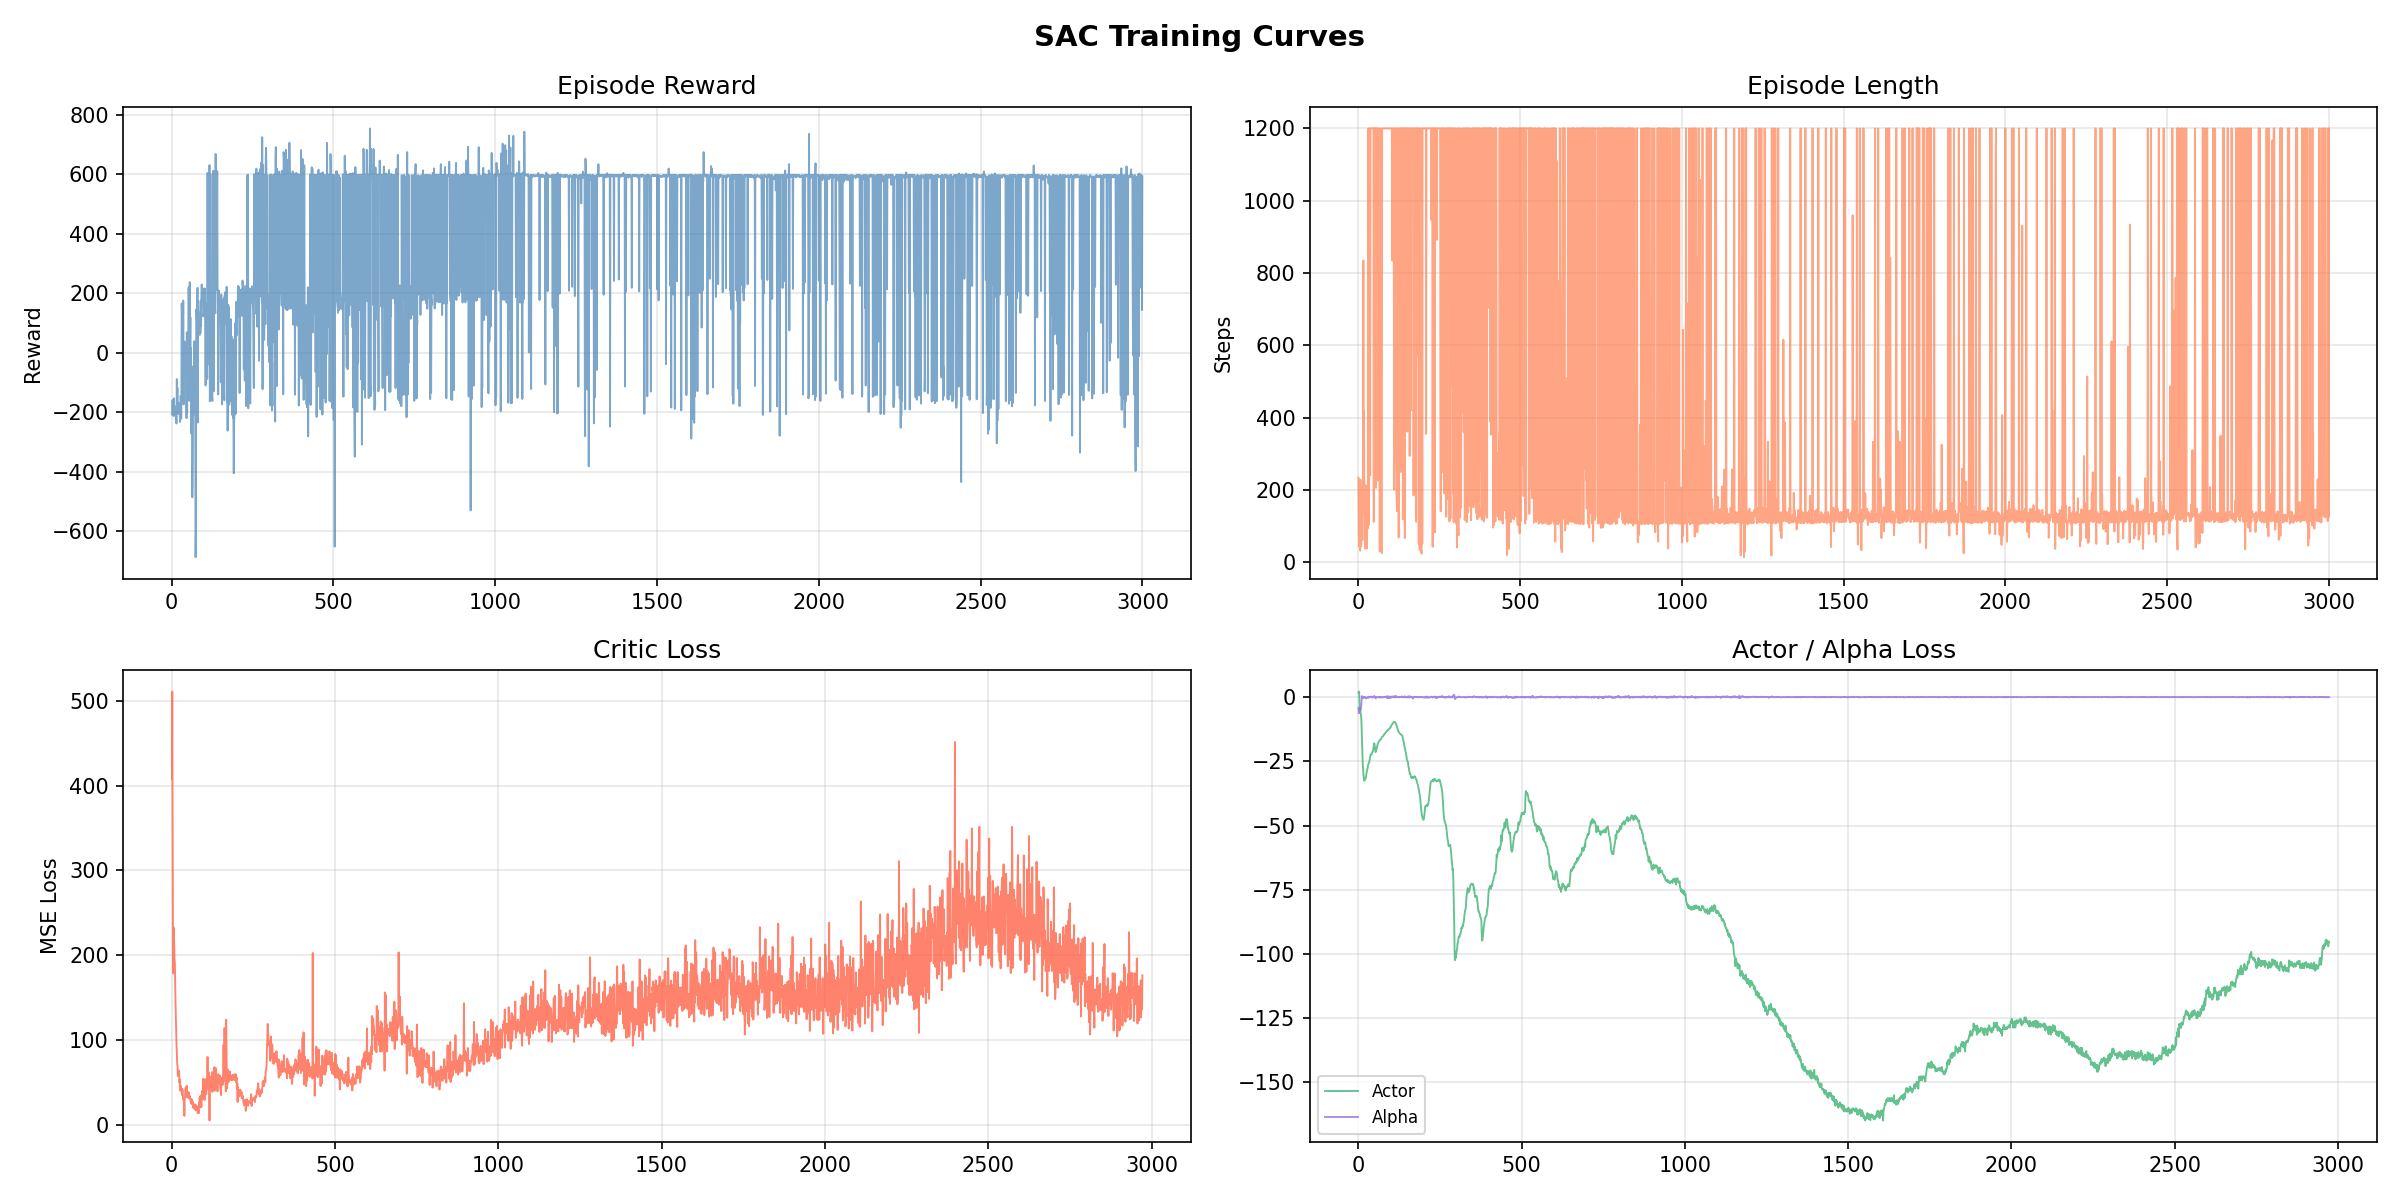

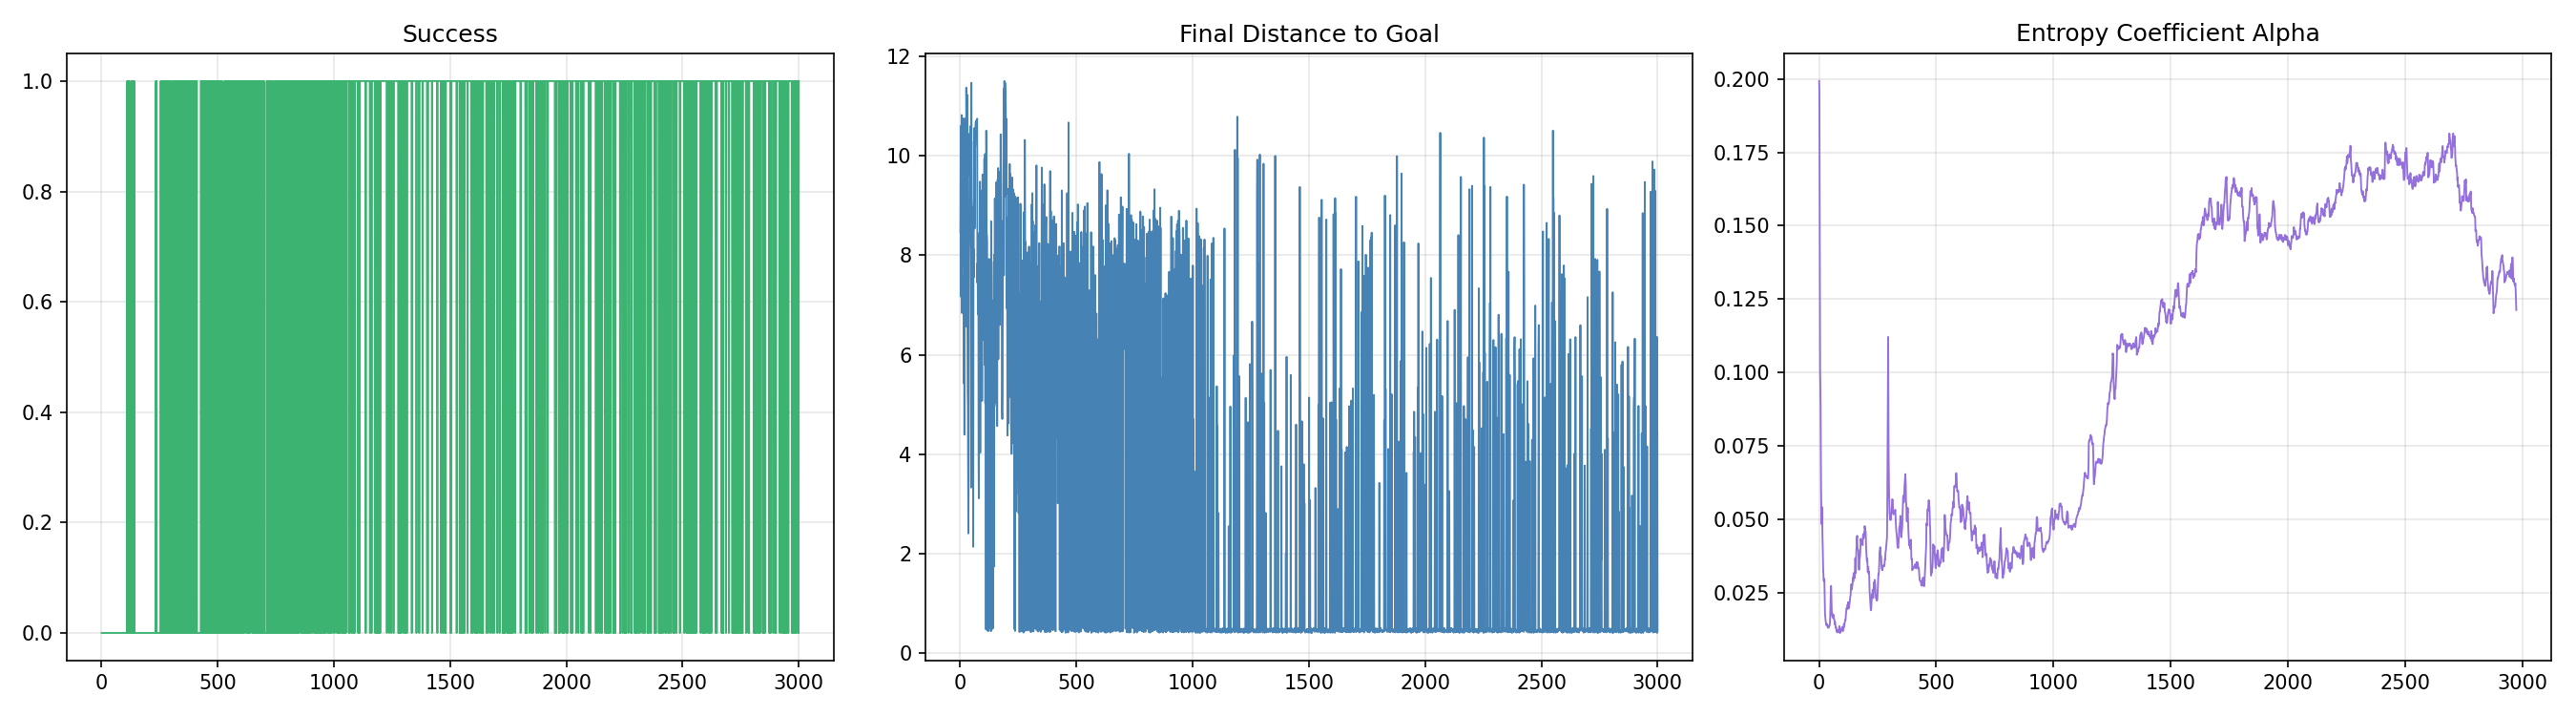

sac_diff_drive_training-episode-0.mp4
sac_diff_drive_training-episode-1000.mp4
sac_diff_drive_training-episode-1500.mp4
sac_diff_drive_training-episode-2000.mp4
sac_diff_drive_training-episode-2500.mp4
sac_diff_drive_training-episode-500.mp4
sac_diff_drive_eval_random_obstacles_greedy-episode-0.mp4


sac_diff_drive_eval_random_obstacles_greedy-episode-1.mp4


sac_diff_drive_eval_random_obstacles_greedy-episode-2.mp4


In [8]:
from IPython.display import Image, Video, display

for image_path in (PLOT_PATH, PLOT_PATH2):
    if image_path.exists():
        display(Image(filename=str(image_path)))

for video_path in sorted(TRAINING_VIDEO_DIR.glob(f"{TRAINING_NAME_PREFIX}*.mp4")):
    print(video_path.name)

for video_path in sorted(EVALUATION_VIDEO_DIR.glob(f"{EVALUATION_NAME_PREFIX}*.mp4")):
    print(video_path.name)
    display(Video(filename=str(video_path), embed=True))